In [48]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
     

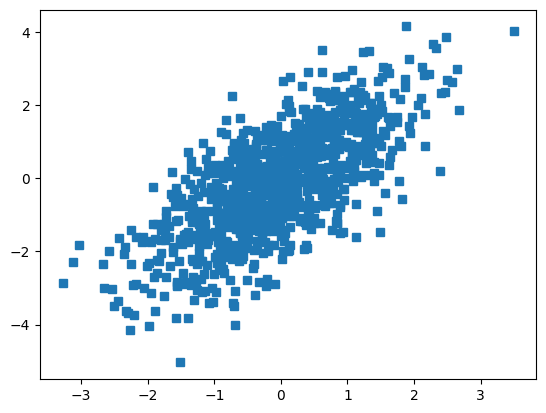

In [49]:
N = 1000
x = torch.randn(N,1)
y = x + torch.randn(N,1)

# and plot
plt.plot(x,y,'s')
plt.show()

In [50]:
# build model
ANNreg = nn.Sequential(
    nn.Linear(1,1),  # input layer
    nn.ReLU(),       # activation function
    nn.Linear(1,1)   # output layer
    )
     
learningRate = .05

lossfun = nn.MSELoss()
optimizer = torch.optim.SGD(ANNreg.parameters(),lr=learningRate)

In [51]:
# # select training data (note the hard-coded N!)
# trainidx  = np.random.choice(range(N),int(.8*N),replace=False) # random indices
# trainBool = np.zeros(N,dtype=bool) # initialize vector of Falses'
# trainBool[trainidx] = True # set selected samples to True

# # show the sizes
# print(x[trainBool].shape)
# print(x[~trainBool].shape)

test_data, train_data, test_labels, train_labels = train_test_split(x,y,train_size=0.8,shuffle=True)


In [52]:
numepochs = 500
losses=[]
for epochi in range(numepochs):

  # forward pass
  yHat = ANNreg(x[trainBool])

  # compute loss
  loss = lossfun(yHat,y[trainBool])

  # backprop
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  losses.append(loss.item())
     
predYtest = ANNreg(x[~trainBool])
testloss = (predYtest-y[~trainBool]).pow(2).mean()

print(f'Final TRAIN loss: {loss.detach():.2f}')
print(f'Final TEST loss: {testloss.detach():.2f}')


Final TRAIN loss: 2.12
Final TEST loss: 1.93


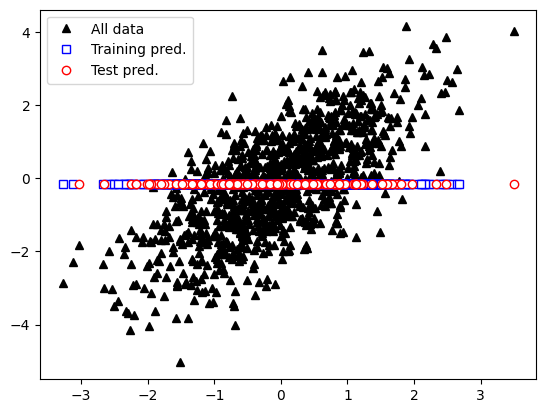

In [54]:
predYtrain = ANNreg(x[trainBool]).detach().numpy()

# now plot
plt.plot(x,y,'k^',label='All data')
plt.plot(x[trainBool], predYtrain,
         'bs',markerfacecolor='w',label='Training pred.')
plt.plot(x[~trainBool],predYtest.detach(),
         'ro',markerfacecolor='w',label='Test pred.')

plt.legend()
plt.show()
     

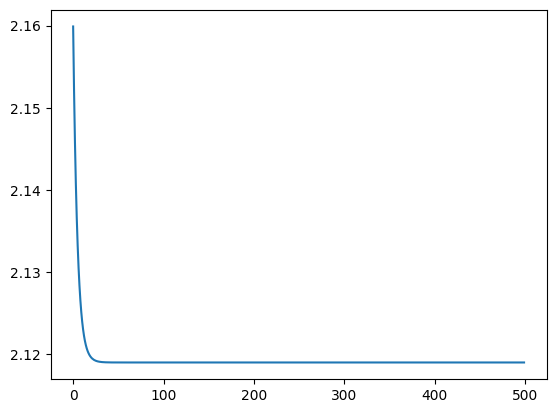

In [55]:
plt.plot(losses)